# Laboratorium 5: Weryfikacja hipotez

Pracujemy na danych `Iris` i pokazujemy pełny, praktyczny workflow testowania hipotez w Pythonie.

## Cele
- sformułować hipotezy zerowe i alternatywne,
- dobrać test do typu danych,
- policzyć p-value, przedziały ufności i wielkość efektu,
- porównać testy parametryczne i nieparametryczne,
- zinterpretować wynik w języku analizy danych.

## Importy

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.datasets import load_iris

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 20)
np.random.seed(42)

## 1. Dane i pytanie badawcze
Porównamy długość płatka `petal length` między gatunkami `setosa` i `versicolor`.

In [2]:
iris = load_iris(as_frame=True)
df = iris.frame.rename(columns={"target": "species_id"})
df["species"] = df["species_id"].map(dict(enumerate(iris.target_names)))
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species_id,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [3]:
subset = df[df["species"].isin(["setosa", "versicolor"])][["species", "petal length (cm)"]].copy()
subset.groupby("species").agg(["mean", "std", "count"])

petal length (cm)                
                        mean       std count
species                                     
setosa                 1.462  0.173664    50
versicolor             4.260  0.469911    50

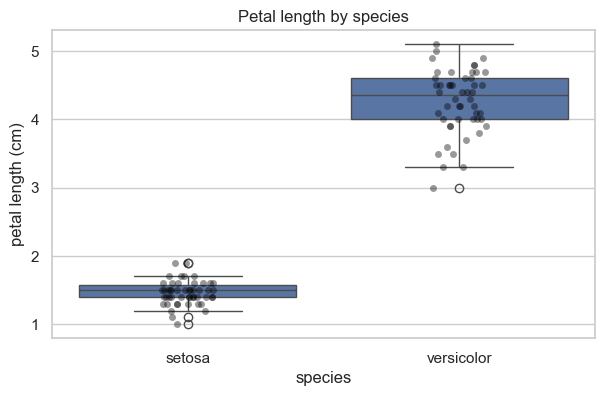

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=subset, x="species", y="petal length (cm)", ax=ax)
sns.stripplot(data=subset, x="species", y="petal length (cm)", color="black", alpha=0.4, ax=ax)
ax.set_title("Petal length by species")
plt.show()

## 2. Jak czytać p-wartość
p-wartość (p-value) to prawdopodobieństwo (liczone w założeniu hipotezy zerowej), że statystyka testowa byłaby tak skrajna jak obserwowana.

W praktyce: p-wartość *nie* jest "prawdopodobieństwem, że hipoteza zerowa jest prawdziwa".

## 3. Test t-Studenta i założenia

In [5]:
x = subset.loc[subset['species'] == 'setosa', 'petal length (cm)'].to_numpy()
y = subset.loc[subset['species'] == 'versicolor', 'petal length (cm)'].to_numpy()
shapiro_x = stats.shapiro(x)
shapiro_y = stats.shapiro(y)
results_shapiro = pd.DataFrame({
    'test': ['Shapiro setosa', 'Shapiro versicolor'],
    'statistic': [shapiro_x.statistic, shapiro_y.statistic],
    'p_value': [shapiro_x.pvalue, shapiro_y.pvalue],
})
results_shapiro


,test,statistic,p_value
0,Shapiro setosa,0.954977,0.054811
1,Shapiro versicolor,0.966004,0.158478


Test Shapiro-Wilka pokazuje, czy próbki pochodzą z rozkładu normalnego. W naszym przypadku `p≈0.055` i `p≈0.158`, czyli nie mamy silnego dowodu na odrzucenie normalności, ale wartości są bliskie progu 0.05. Gdyby jedna z prób zwróciła `p<0.05`, oznaczałoby to, że tę próbę traktujemy jako nienormalną i powinniśmy rozważyć test nieparametryczny (albo transformację), zamiast polegać na klasycznym teście t.


In [6]:
levene = stats.levene(x, y)
print(f'Levene stat = {levene.statistic:.3f}, p = {levene.pvalue:.3e}')


Levene stat = 30.500, p = 2.744e-07


Levene mierzy, czy wariancje są równe; tu `p≈2.7e-07`, co oznacza, że wariancje różnią się istotnie. W takiej sytuacji nie zakładamy równości wariancji i wybieramy test Welcha (z `equal_var=False`). Gdyby wynik był `p>0.05`, można by użyć klasycznego testu t dla równych wariancji, ale w tym przypadku musimy być ostrożni wobec wskazanych różnic w wariancjach.


In [7]:
ttest = stats.ttest_ind(x, y, equal_var=False)
results_ttest = pd.DataFrame({
    'test': ['Welch t-test'],
    'statistic': [ttest.statistic],
    'p_value': [ttest.pvalue],
})
results_ttest


,test,statistic,p_value
0,Welch t-test,-39.492719,9.934433e-46


Test Welcha daje `p≈1e-45`, co pokazuje, że różnice średnich są istotne nawet po uwzględnieniu nierówności wariancji. To odpowiada pytaniu badawczemu: średnia długość płatków `setosa` jest istotnie mniejsza niż `versicolor`. Warto też zwrócić uwagę na kolejność analiz: najpierw sprawdzamy założenia (normalność i wariancje), a potem przechodzimy do testu, który najlepiej pasuje do ich wyniku.


In [8]:
mean_diff = x.mean() - y.mean()
se = np.sqrt(x.var(ddof=1)/len(x) + y.var(ddof=1)/len(y))
ci_low, ci_high = stats.t.interval(0.95, df=len(x) + len(y) - 2, loc=mean_diff, scale=se)
print(f'mean difference = {mean_diff:.3f}')
print(f'95% CI approx. = [{ci_low:.3f}, {ci_high:.3f}]')


mean difference = -2.798
95% CI approx. = [-2.939, -2.657]


Interpretacja wyników i przedziału ufności:
- Różnica średnich (`x.mean() - y.mean()`) wynosi około `-2.798`, czyli `setosa` ma krótsze płatki niż `versicolor`.
- `se` oszacowuje niepewność tej różnicy, a przedział ufności `[-2.939, -2.657]` nie zawiera zera, co dodatkowo potwierdza istotność statystyczną i pozwala komunikować wielkość efektu wraz z niepewnością.
- Takie wyliczenia są kluczowe, gdy raportujemy wyniki: pokazujemy, że nie tylko `p<0.05`, ale także jak duża może być różnica oraz jak pewni jesteśmy tego oszacowania.


## 4. Test U Manna-Whitneya

Test U Manna-Whitneya porównuje mediany dwóch niezależnych prób na podstawie rang, więc jest dobry, gdy dane nie spełniają założeń normalności lub gdy mamy obserwacje porządkowe. Dzięki przekształceniu wartości w rangi, test skupia się na porządkowych relacjach między obserwacjami (czyli jak wartości się układają względem siebie), a nie na samych wartościach liczbowych.
Wynik `statistic≈0` i `p≈5.65e-18` oznacza, że rangi dla `setosa` i `versicolor` są tak różne, że możemy odrzucić hipotezę zerową o takim samym rozkładzie. Innymi słowy – różnice między grupami są widoczne niezależnie od przyjętych założeń o kształcie rozkładów.


In [9]:
mw = stats.mannwhitneyu(x, y, alternative="two-sided")
print(mw)

MannwhitneyuResult(statistic=np.float64(0.0), pvalue=np.float64(5.651011584290147e-18))


Wniosek: rangi różnią się na tyle, że `p≈5.65e-18`, więc odrzucamy hipotezę zerową o takim samym rozkładzie.

### Test U Manna-Whitneya krok po kroku
1. Łączymy obserwacje z obu grup i przypisujemy im przynależność,
2. Przekształcamy wartości w rangi, co pozwala porównać pozycje obserwacji względem siebie,
3. Sumujemy rangi dla każdej grupy, a następnie obliczamy statystykę U (rządowo zabieramy `n*(n+1)/2` dla danej grupy).
4. Wartość U informuje nas, ile razy obserwacje jednej grupy znajdują się przed obserwacjami drugiej grupy.


In [10]:
df_ranks = pd.DataFrame({
    "value": np.concatenate([x, y]),
    "group": ["setosa"] * len(x) + ["versicolor"] * len(y),
})
df_ranks["rank"] = stats.rankdata(df_ranks["value"])
rank_summary = df_ranks.groupby("group")["rank"].sum()
n1 = len(x)
n2 = len(y)
U_setosa = rank_summary["setosa"] - n1 * (n1 + 1) / 2
U_versicolor = rank_summary["versicolor"] - n2 * (n2 + 1) / 2
U_min = min(U_setosa, U_versicolor)
expected_U = n1 * n2 / 2
std_U = np.sqrt(n1 * n2 * (n1 + n2 + 1) / 12)
z_score = (U_min - expected_U) / std_U
print(df_ranks.head())
print(rank_summary.rename("rank_sum"))
print(f"U_setosa={U_setosa:.1f}, U_versicolor={U_versicolor:.1f}, U_min={U_min:.1f}")
print(f"expected_U={expected_U:.1f}, std_U={std_U:.3f}, z≈{z_score:.2f}")


   value   group  rank
0    1.4  setosa  18.0
1    1.4  setosa  18.0
2    1.3  setosa   8.0
3    1.5  setosa  31.0
4    1.4  setosa  18.0
group
setosa        1275.0
versicolor    3775.0
Name: rank_sum, dtype: float64
U_setosa=0.0, U_versicolor=2500.0, U_min=0.0
expected_U=1250.0, std_U=145.057, z≈-8.62


Wartość `U_min` informuje, jak bardzo rangi jednej grupy są przesunięte względem drugiej;
im bliżej zera, tym większe różnice.
Zatem `z≈-8.6` potwierdza, że obserwacje `setosa` są systematycznie mniejsze od `versicolor` nawet na poziomie rang.
Po ręcznym obliczeniu widzimy tę samą narrację, co w funkcji `stats.mannwhitneyu`.

## 5. Bootstrap dla różnicy średnich

Bootstrap pozwala oszacować rozkład statystyki poprzez wielokrotne losowanie z próby z zastępowaniem, dzięki czemu nie musimy zakładać konkretnego rozkładu danych.
W praktyce w tym rozdziale generujemy 2000 różnic średnich (po jednej dla każdego resamplingu), co daje empiryczny rozkład tej statystyki.
Przedział ufności z bootstrapu (kwantyle 2.5% i 97.5%) to bezpośrednie oszacowanie zakresu, w którym różnica średnich prawdopodobnie się mieści, co daje pewną alternatywę dla klasycznych wariantów testów parametrycznych.


{'bootstrap_ci': (np.float64(-2.93205), np.float64(-2.6579999999999995)), 'boot_mean': np.float64(-2.7993110000000003)}


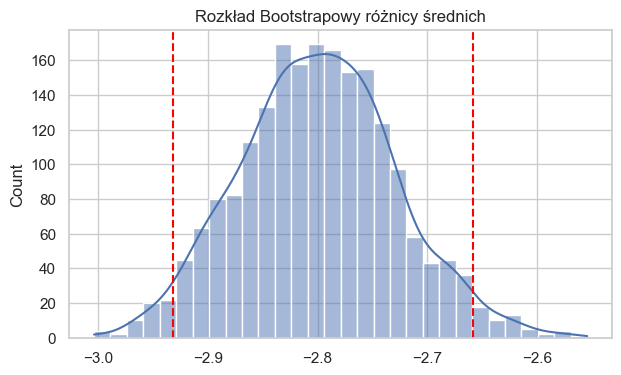

In [11]:
boot_diffs = []
for _ in range(2000):
    xb = np.random.choice(x, size=len(x), replace=True)
    yb = np.random.choice(y, size=len(y), replace=True)
    boot_diffs.append(xb.mean() - yb.mean())
boot_diffs = np.array(boot_diffs)
ci = np.quantile(boot_diffs, [0.025, 0.975])
print({"bootstrap_ci": tuple(ci), "boot_mean": boot_diffs.mean()})
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(boot_diffs, bins=30, kde=True, ax=ax)
ax.axvline(ci[0], color="red", linestyle="--")
ax.axvline(ci[1], color="red", linestyle="--")
ax.set_title("Rozkład Bootstrapowy różnicy średnich")
plt.show()

## 6. Zadanie na zajęcia
Dla swoich danych opisz co testujesz, jakiego użyjesz testu i dlaczego (jakie założenia testu mają sens dla danych), a następnie jaka jest statystyka i wynik (p-wartość), przedział ufności (jeśli ma zastosowanie) i jak to interpretujesz dla swojego pytania badawczego.